### ReAct Agent Architecture

#### Aim
This is the intuition behind ReAct, a general agent architecture.

1. act - let the model call specific tools
2. observe - pass the tool output back to the model
3. reason - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)

![image.png](attachment:image.png)

In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [2]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [5]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [9]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [10]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical optimisation me'

In [11]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"]="ReAct-agent"

In [12]:
### Custom Functions
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools=[arxiv,wiki,add,multiply,divide]

In [6]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\pc\AppData\Local\Temp\ipykernel_12584\3584238.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [7]:
tavily.invoke("Provide me the recent AI news for march 3rd 2025")

[{'title': 'Artificial Intelligence - AI Update, March 28, 2025: AI News and Views From the Past Week',
  'url': 'https://www.marketingprofs.com/opinions/2025/52941/ai-update-march-28-2025-ai-news-and-views-from-the-past-week',
  'content': "DeepSeek releases upgraded V3 model, escalating competition with OpenAI. Chinese AI startup DeepSeek has launched an upgraded version of its V3 large language model, enhancing reasoning and coding abilities. Published on Hugging Face, the new model shows strong performance across technical benchmarks. This release follows earlier models, including V3 and R1, positioning DeepSeek as a serious contender to OpenAI and Anthropic. The company emphasizes lower operational costs, helping it compete globally. The release underscores China's growing momentum in foundational AI research and deployment. Importance for marketers: DeepSeek's advancements may broaden options for generative AI tools and reduce dependency on US models, especially for cost-consciou

In [13]:
tools=[arxiv,wiki,tavily,add,divide,multiply]

In [14]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant")


d:\2026-courses\agenticai\langraph\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
llm_with_tools=llm.bind_tools(tools)

In [16]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'nwhrknsqt', 'function': {'arguments': '{"query":"Recent AI News"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 744, 'total_tokens': 764, 'completion_time': 0.043810519, 'completion_tokens_details': None, 'prompt_time': 0.496463036, 'prompt_tokens_details': None, 'queue_time': 0.131367175, 'total_time': 0.540273555}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_d9492c3c54', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e1b06-931e-75c1-a149-7f6d75b11809-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Recent AI News'}, 'id': 'nwhrknsqt', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 744, 'output_tokens': 20, 'total_tokens': 764})

In [17]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'AI News'},
  'id': 'yar21pr5v',
  'type': 'tool_call'}]

In [18]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

d:\2026-courses\agenticai\langraph\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [19]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools","tool_calling_llm")


graph = builder.compile()

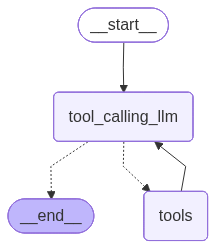

In [20]:
# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 2 recent AI news for MArch 3rd 2025,add 5 plus 5 and then multiply by 10")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 2 recent AI news for MArch 3rd 2025,add 5 plus 5 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (17x86rmcn)
 Call ID: 17x86rmcn
  Args:
    query: recent AI news March 3rd 2025
  tavily_search_results_json (awf61kzf9)
 Call ID: awf61kzf9
  Args:
    query: recent AI news March 3rd 2025
  add (p169c3bd1)
 Call ID: p169c3bd1
  Args:
    a: 5
    b: 5
  multiply (rgy6yphpg)
 Call ID: rgy6yphpg
  Args:
    a: 15
    b: 10
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Weekly AI News: 3 March 2025 - AIforBusiness.net", "url": "https://www.linkedin.com/pulse/weekly-ai-news-3-march-2025-aiforbusinessnet-johan-steyn-qrumf", "content": "A thought-provoking analysis in the Daily Maverick questions AI’s growing influence,